In [26]:
import os
import time

import numpy as np
import pandas as pd
import timm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

# Test Data Preprocessing

In [27]:
test_dataset_path = './test/'

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

filenames = sorted(os.listdir(test_dataset_path), key=lambda x: int(os.path.splitext(x)[0]))

transformed_images = []
raw_images = []
image_names = []

for filename in filenames:
    image_path = os.path.join(test_dataset_path, filename)
    image = Image.open(image_path)
    raw_images.append(image)
    transformed_image = test_transform(image)
    transformed_images.append(transformed_image)
    image_names.append(filename)


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\PIL\TiffImagePlugin.py:890: UserWarning: Truncated File Read
  warnings.warn(str(msg))
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\PIL\JpegImagePlugin.py:853: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


# CNN Model Setup

In [28]:
# Define the model architecture
resnet152_model = models.resnet152(weights='DEFAULT')
num_features = resnet152_model.fc.in_features
num_classes = 4 
resnet152_model.fc = nn.Linear(num_features, num_classes)

# Load the trained weights
resnet152_trained_model = "CNN_transfer_learning/models/resnet152_1.pth"
resnet152_state_dict = torch.load(resnet152_trained_model) 
resnet152_model.load_state_dict(resnet152_state_dict)

<All keys matched successfully>

# VIT Model Setup

In [29]:
# Define the model architecture
swin_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes = 4, global_pool='avg')
swin_model_trained = "VIT_transfer_learning/models/swin_tiny_1.pth"

# Load the trained weights
swin_state_dict = torch.load(swin_model_trained)
swin_model.load_state_dict(swin_state_dict)

<All keys matched successfully>

# Test Models

In [37]:
def predict_image(model, image, device):
    class_names = ["cordona", "healthy", "pestalotiopsis", "sigatoka"]
    image = image.unsqueeze(0) 
    model.eval()
    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output.data, 1)
    
    predicted_label = class_names[pred.item()]
    return predicted_label

# CNN Predictions

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

CNN_output = "outputs/CNN_output.xlsx"
CNN_results = []

since = time.time()
for image_tensor, filename in zip(transformed_images, image_names):
    predicted_label = predict_image(resnet152_model, image_tensor, device)
    CNN_results.append((filename, predicted_label))
time_elapsed = time.time() - since
print(f'Evaluation complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

df = pd.DataFrame(CNN_results, columns=["image_filename", "predicted_label"])
df.to_excel(CNN_output, index=False)

Using cpu device
Evaluation complete in 0m 27s


# VIT Predictions

In [39]:
print(f"Using {device} device")
VIT_output = "outputs/VIT_output.xlsx"
VIT_results = []

since = time.time()
for image_tensor, filename in zip(transformed_images, image_names):
    predicted_label = predict_image(swin_model, image_tensor, device)
    VIT_results.append((filename, predicted_label))
time_elapsed = time.time() - since
print(f'Evaluation complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

df = pd.DataFrame(VIT_results, columns=["image_filename", "predicted_label"])
df.to_excel(VIT_output, index=False)

Using cpu device
Evaluation complete in 0m 14s


# Show Image with Prediction

In [33]:
def show_image(transformed_image, raw_image, label, filename, model):
    image = transformed_image.cpu().numpy()
    image = np.transpose(image, (1, 2, 0))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(raw_image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(image)
    axes[1].set_title('Transformed Image')
    axes[1].axis('off')

    fig.suptitle(f'{filename}: {label} ({model})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Demo

Using cpu device


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


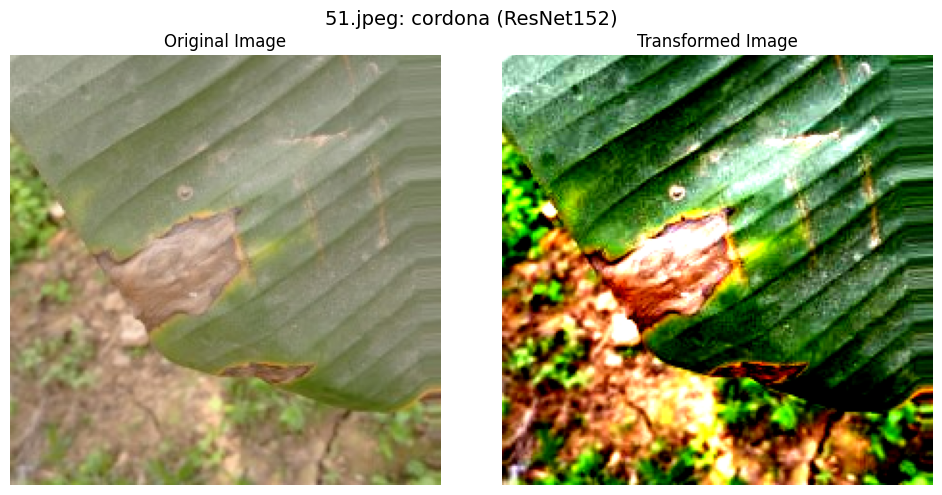

In [41]:
print(f"Using {device} device")

# model = swin_model
# model_name = "Swin-tiny"
model = resnet152_model
model_name = "ResNet152"

index = 51
filename = str(index) + ".jpeg"
image_tensor = transformed_images[index]
raw_image = raw_images[index]

predicted_label = predict_image(model, image_tensor, device)
show_image(image_tensor, raw_image, predicted_label, filename, model_name)